# 🎭 Sentiment Analyser: End-to-End NLP Pipeline

Welcome! In this notebook, we are going to build a sentiment classification pipeline from scratch. 
We'll clean movie reviews, look at word distributions (EDA), train a Logistic Regression model with TF-IDF features, evaluate it, and save the model so our Streamlit app can use it! 🍿✨

## 1. ⚙️ Setup & Imports

Let's import the necessary libraries first. We need standard data science tools (`pandas`, `numpy`, `matplotlib`, `seaborn`) along with NLP tools (`scikit-learn` and `wordcloud`).

In [1]:
import os
import re
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from wordcloud import WordCloud 
import nltk
from nltk.corpus import stopwords

print("✅ Setup completed successfully!")

✅ Setup completed successfully!


## 2. 📖 Loading the Dataset

We load the movie review dataset from `../dataset/IMDB Dataset.csv` which contains the reviews and their sentiments ('positive' or 'negative').

In [2]:
dataset_path = '../dataset/IMDB Dataset.csv'

# Load data
df = pd.read_csv(dataset_path)
print(f"📊 Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

📊 Dataset loaded with 50000 rows and 2 columns.


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 3. 🧹 Text Preprocessing

Movie reviews contain noise like HTML breaks (`<br />`), punctuation, capital letters, and generic words (stopwords like 'the', 'is', etc.). 
Let's clean that up! We'll:
- Convert all reviews to lowercase.
- Remove HTML tags using a regex.
- Remove punctuation & numbers.
- Download and filter out standard NLTK stopwords.

In [3]:
# Download and import NLTK stopwords
nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    # Remove HTML tags
    text = re.sub(r'<[^>]*>', ' ', text)
    # Lowercase
    text = text.lower()
    # Keep only alphabetical words
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Stopword removal
    words = text.split()
    cleaned_words = [w for w in words if w not in STOPWORDS]
    return " ".join(cleaned_words)

print("🧹 Cleaning reviews (this might take a few seconds)...")
df['cleaned_review'] = df['review'].apply(clean_text)
df[['review', 'cleaned_review', 'sentiment']].head()

[nltk_data] Downloading package stopwords to C:\Users\Amarjeet
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


🧹 Cleaning reviews (this might take a few seconds)...


,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,positive


## 4. 📊 Exploratory Data Analysis (EDA)

Let's check if the positive and negative review classes are balanced.

C:\Users\Amarjeet Singh\AppData\Local\Temp\ipykernel_18632\901189253.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='Set2')


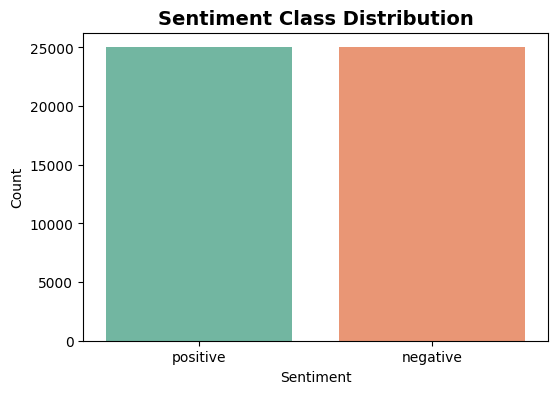

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='Set2')
plt.title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

Now let's check what words stand out the most in positive reviews using a WordCloud! ☁️

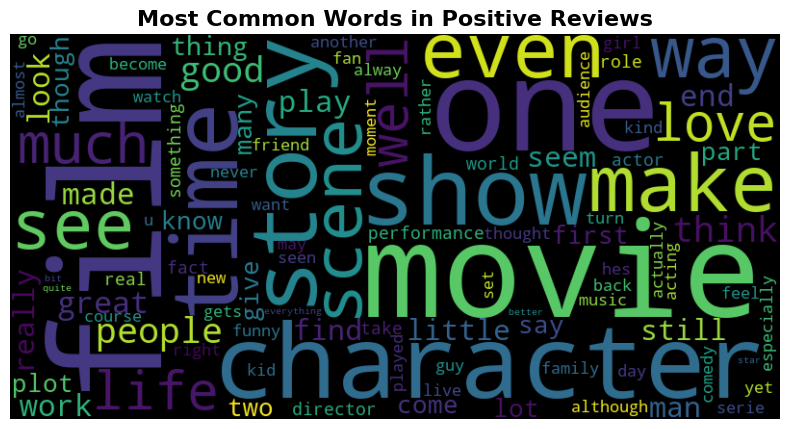

In [5]:
pos_text = " ".join(df[df['sentiment'] == 'positive']['cleaned_review'])
if pos_text.strip():
    pos_wordcloud = WordCloud(width=800, height=400, background_color='black', 
                              colormap='viridis', max_words=100).generate(pos_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(pos_wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Common Words in Positive Reviews', fontsize=16, fontweight='bold')
    plt.show()

Let's do the same for negative reviews! ☁️

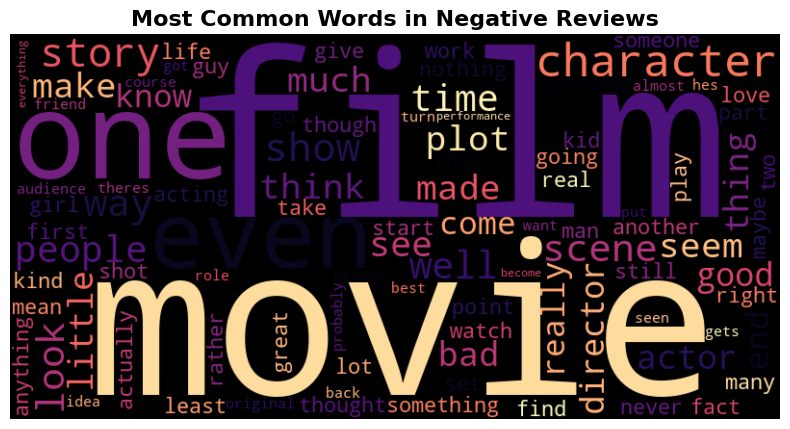

In [6]:
neg_text = " ".join(df[df['sentiment'] == 'negative']['cleaned_review'])
if neg_text.strip():
    neg_wordcloud = WordCloud(width=800, height=400, background_color='black', 
                              colormap='magma', max_words=100).generate(neg_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(neg_wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Most Common Words in Negative Reviews', fontsize=16, fontweight='bold')
    plt.show()

## 5. ⚡ Feature Engineering & Vectorization

Machine learning models can't read text directly, so we use **TF-IDF** (Term Frequency - Inverse Document Frequency). 
We'll split our dataset into train (80%) and test (20%) sets first.

In [7]:
# Encode Labels: positive = 1, negative = 0
y = df['sentiment'].map({'positive': 1, 'negative': 0})
X = df['cleaned_review']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# Vectorizer configuration
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

print(f"TF-IDF Matrix Shape (Train): {X_train_vectorized.shape}")

Train size: 40000 | Test size: 10000
TF-IDF Matrix Shape (Train): (40000, 10000)


## 6. 🏋️ Model Training

We are using a **Logistic Regression** classifier. It is simple, extremely fast to train, and highly effective for TF-IDF feature representations!

In [8]:
model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train_vectorized, y_train)
print("🏋️ Model trained successfully!")

🏋️ Model trained successfully!


## 7. 🎯 Evaluation

Let's see how our model performs on the test set!

In [9]:
y_pred = model.predict(X_test_vectorized)
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {accuracy * 100:.2f}%")
print("\n📝 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

🎯 Model Accuracy: 89.76%

📝 Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.89      0.90      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## 8. 💾 Save the Model

Finally, we pickle our vectorizer and model to use them inside our Streamlit app! 📦

In [10]:
os.makedirs('../models', exist_ok=True)

with open('../models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("💾 Pickled sentiment_model.pkl and tfidf_vectorizer.pkl to '../models/' directory!")

💾 Pickled sentiment_model.pkl and tfidf_vectorizer.pkl to '../models/' directory!
